# Upper Freda Formation ca. 1045 Ma paleomagnetic pole

## Geologic context

The Freda Formation is the uppermost unit of the Oronto Group, the post-rift
fluvial–lacustrine clastic fill of the North American Midcontinent Rift exposed
along the south shore of Lake Superior. Its red-bed sandstones and siltstones
were deposited after the cessation of rift volcanism and record the waning of
Laurentia's rapid late-Mesoproterozoic plate motion as the Grenvillian orogeny
began (Fuentes et al., 2025). This pole is for the **upper Freda Formation** and
is built from the **Wolf Point section**, which has nearly flat-lying beds
(~4° dip) and lies outside the Montreal River Monocline / Ashland Syncline
structural domain, minimizing the vertical-axis rotation that affects other
Freda sections.

This notebook follows the data and processing of the Fuentes et al. (2025) study
repository (`github.com/Swanson-Hysell-Group/Upper_Freda_Pole`). The
inclination-shallowing correction is computationally intensive (an SVEI
elongation/inclination Monte Carlo), so its result — the best-fit flattening
factor and the Kent-ellipse pole uncertainty — is **taken directly from Fuentes
et al. (2025)** rather than recomputed here; we reproduce the uncorrected pole
from the archived specimen directions and apply the published flattening factor.

## Paleomagnetic and rock magnetic data

The characteristic remanence is a detrital remanent magnetization (DRM) carried
by **specularite** (coarse-grained, >1 µm detrital gray hematite), isolated as a
high-unblocking-temperature (HT) component by stepwise thermal demagnetization
with steps narrowed to 2 °C approaching the hematite Néel temperature (~690 °C)
and fit by principal-component analysis. A distinct mid-temperature (MT)
component carried by fine pigmentary hematite is a chemical remanent
magnetization (CRM). The specularite DRM origin is supported by SEM imaging,
EDS spectroscopy, and EBSD on polished thick sections.

The pole is the Fisher mean of the Wolf Point HT specimen VGPs (n = 90,
tilt-corrected). Because detrital hematite acquires a shallowed (flattened)
inclination on deposition and compaction, an inclination-shallowing correction
is applied.

## Inclination-shallowing correction

The flattening factor is estimated with the SVEI elongation/inclination method
(Tauxe et al., 2024): Fuentes et al. (2025) find a best-fit **f = 0.73** with a
95% range of **0.59–0.87** (via `pmagpy.svei.find_flat`; that elongation search
is slow, ~minutes, and is not rerun here). That flattening range is propagated to
the pole as a Kent ellipse with the Monte Carlo approach of Pierce et al. (2022),
implemented in `ipmag.find_svei_kent`, which we **run on the data below** to
reproduce the corrected pole and its uncertainty directly from the specimen
directions.

## Age constraints

- Best estimate **ca. 1045 Ma**. The Bayesian thermal-subsidence age model of
  Fuentes et al. (2025) gives 1045.0 Ma with 95% credible bounds of
  1063.2 / 1031.7 Ma (+18.2/−13.3 Ma) for the upper Freda pole. It integrates the
  U-Pb CA-ID-TIMS detrital-zircon maximum depositional age of 1051.6 ± 1.1 Ma
  from ~4 km above the Freda base (Hodgin et al., 2024) with minimum-age
  constraints from a Rb-Sr biotite age of 1049 ± 19 Ma (Cannon, 1992) and a U-Pb
  calcite date of 1049 ± 13 Ma from the Douglas Fault (Hodgin et al., 2024) that
  record the Ottawan-stage contractional inversion ending Freda deposition.
- The asymmetric upper bound (+18.2 Ma) slightly exceeds ±15 Ma, which bears on
  the R1 score below.

## References

### Paleomagnetism

- Fuentes, A. J., Fairchild, L. M., Hodgin, E. B., Alemu, T., & Swanson-Hysell, N. L. (2025). Termination of Laurentia's rapid plate motion at the start of the Grenvillian Orogeny. *Journal of Geophysical Research: Solid Earth*, 130, e2025JB031794. https://doi.org/10.1029/2025JB031794

### Geochronology

- Hodgin, E. B., Swanson-Hysell, N. L., Kylander-Clark, A. R. C., Turner, A. C., et al. (2024). One billion years of stability in the North American midcontinent following two-stage Grenvillian deformation. *Tectonics*, 43, e2024TC008415. https://doi.org/10.1029/2024TC008415
- Cannon, W. F. (1992). The Midcontinent Rift in the Lake Superior region with emphasis on its geodynamic evolution. *Tectonophysics*, 213(1–2), 41–48. https://doi.org/10.1016/0040-1951(92)90250-A

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Specimen-level data (Wolf Point section)

The data come from the published Fuentes et al. (2025) MagIC contribution
[20259](https://earthref.org/MagIC/20259). The pole uses the Wolf Point (`WP`)
high-temperature (`HT`) specimen directions in tilt-corrected coordinates
(`dir_tilt_correction == 100`); the specimen table is read from
`../data/1045_Upper_Freda/specimens.txt`. Site VGPs are computed at the Wolf
Point locality (47.0°N, 271.0°E).

In [2]:
study_lat, study_lon = 47.0, 271.0   # Wolf Point locality

specimens = pd.read_csv('../data/1045_Upper_Freda/specimens.txt', sep='\t', skiprows=1)
wp = specimens[specimens['sample'].astype(str).str.contains('WP', na=False)].copy()
wp['lat'] = study_lat
wp['lon'] = study_lon
wp = ipmag.vgp_calc(wp, tilt_correction='no', site_lon='lon', site_lat='lat',
                    dec_is='dir_dec', inc_is='dir_inc')

# high-temperature (specularite DRM) component, tilt-corrected
wp_HT = wp[(wp['dir_comp'] == 'HT') & (wp['dir_tilt_correction'] == 100)].reset_index(drop=True)
print(f'{len(wp_HT)} Wolf Point HT specimens (tilt-corrected)')
wp_HT[['specimen', 'sample', 'dir_dec', 'dir_inc', 'dir_tilt_correction',
       'vgp_lat', 'vgp_lon']].head()

90 Wolf Point HT specimens (tilt-corrected)


,specimen,sample,dir_dec,dir_inc,dir_tilt_correction,vgp_lat,vgp_lon
0,WP.10a,WP.10,277.8,-0.3,100.0,5.200587,175.176814
1,WP.11a,WP.11,274.1,0.6,100.0,3.014571,178.203675
2,WP.12a,WP.12,274.1,0.7,100.0,3.051179,178.237787
3,WP.13a,WP.13,274.8,0.3,100.0,3.381419,177.587966
4,WP.14a,WP.14,276.1,-29.0,100.0,-7.209359,165.983684


## Uncorrected (flattened) mean direction and pole

In [3]:
dir_mean = ipmag.fisher_mean(dec=wp_HT['dir_dec'].tolist(), inc=wp_HT['dir_inc'].tolist())
print('Uncorrected (flattened) mean direction:')
ipmag.print_direction_mean(dir_mean)

flat_pole = ipmag.fisher_mean(wp_HT['vgp_lon'].tolist(), wp_HT['vgp_lat'].tolist())
print('\nUncorrected (flattened) pole:')
ipmag.print_pole_mean(flat_pole)

Uncorrected (flattened) mean direction:
Dec: 281.5  Inc: -7.9
Number of directions in mean (n): 90
Angular radius of 95% confidence (a_95): 2.8
Precision parameter (k) estimate: 28.4

Uncorrected (flattened) pole:
Plon: 169.8  Plat: 4.7
Number of directions in mean (n): 90
Angular radius of 95% confidence (A_95): 2.1
Precision parameter (k) estimate: 49.8


## Inclination-shallowing-corrected pole (SVEI, run on the data)

We unflatten the HT inclinations with the SVEI flattening factor f = 0.73
(`ipmag.unsquish`) to recompute the mean direction and the corrected Fisher pole,
and run `ipmag.find_svei_kent` on the specimen directions to propagate the full
flattening range (0.59–0.87) to the corrected pole as a Kent ellipse (Pierce et
al., 2022). Both reproduce the values of Fuentes et al. (2025). The
flattening-factor uncertainty makes the corrected pole's true confidence region
an ellipse; the Nordic compilation stores a single A95, for which we use the
equal-area-circle approximation of the Kent ellipse, `sqrt(zeta95*eta95)`.

Inclination-corrected mean direction (f = 0.73):
Dec: 281.5  Inc: -10.4
Number of directions in mean (n): 90
Angular radius of 95% confidence (a_95): 3.4
Precision parameter (k) estimate: 20.1

Inclination-corrected pole (f = 0.73):
Plon: 168.8  Plat: 3.7
Number of directions in mean (n): 90
Angular radius of 95% confidence (A_95): 2.4
Precision parameter (k) estimate: 40.2


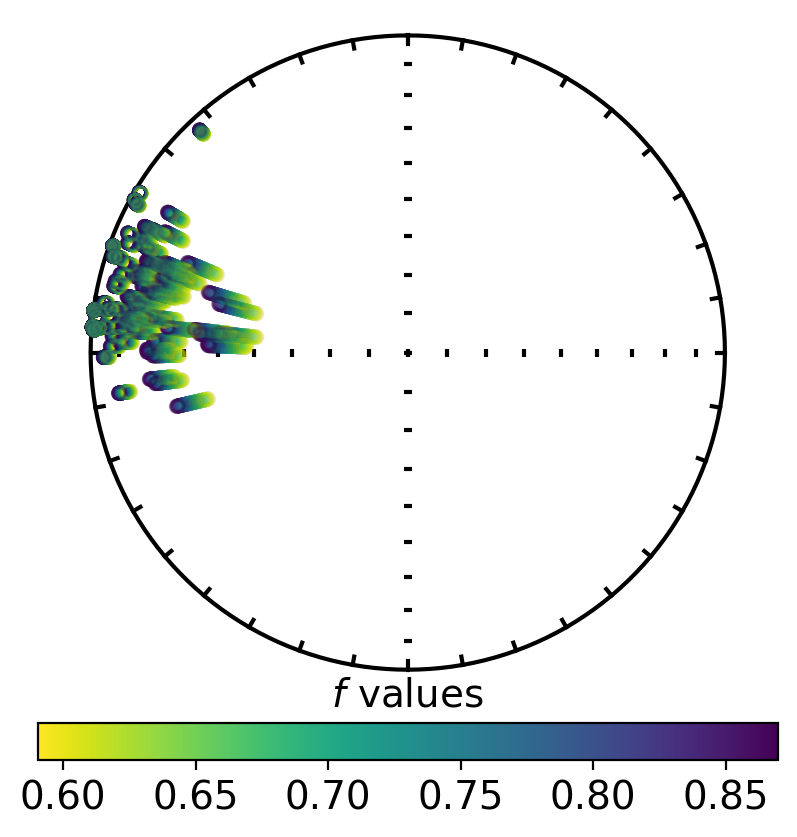

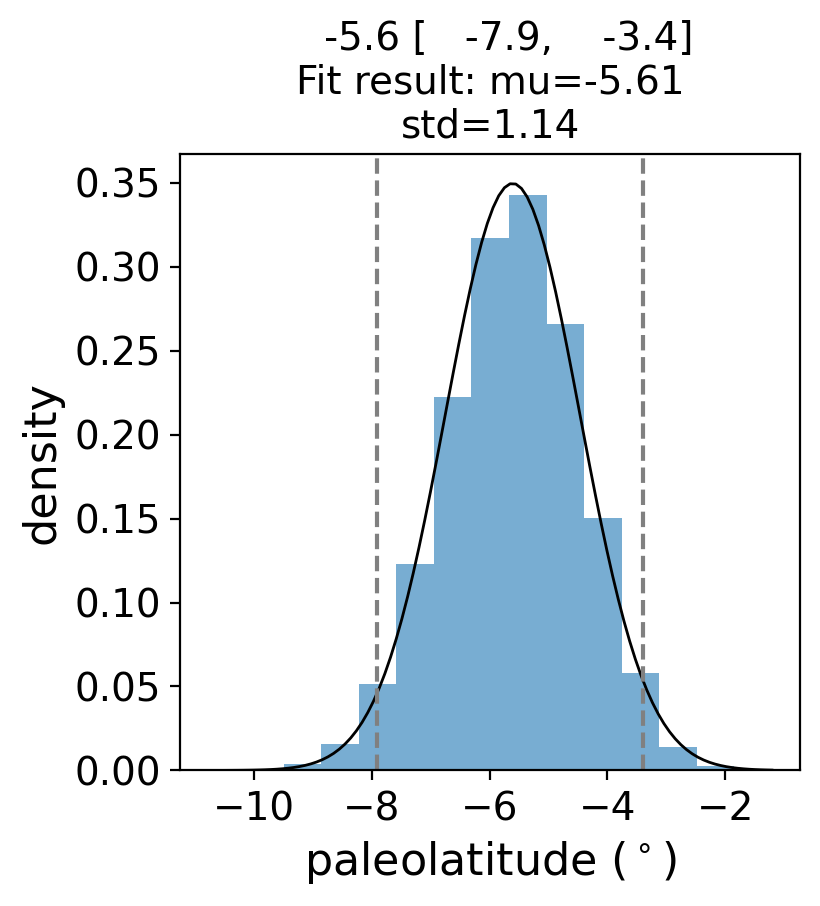

Plon: 168.8  Plat: 3.6
Major axis lon: 262.8  Major axis lat: 47.8
Minor axis lon: 75.5  Minor axis lat: 42.0
Major axis angle of 95% ellipse (Zeta): 2.8
Minor axis angle of 95% ellipse (Eta): 2.4
Number of directions in mean (n): 100000


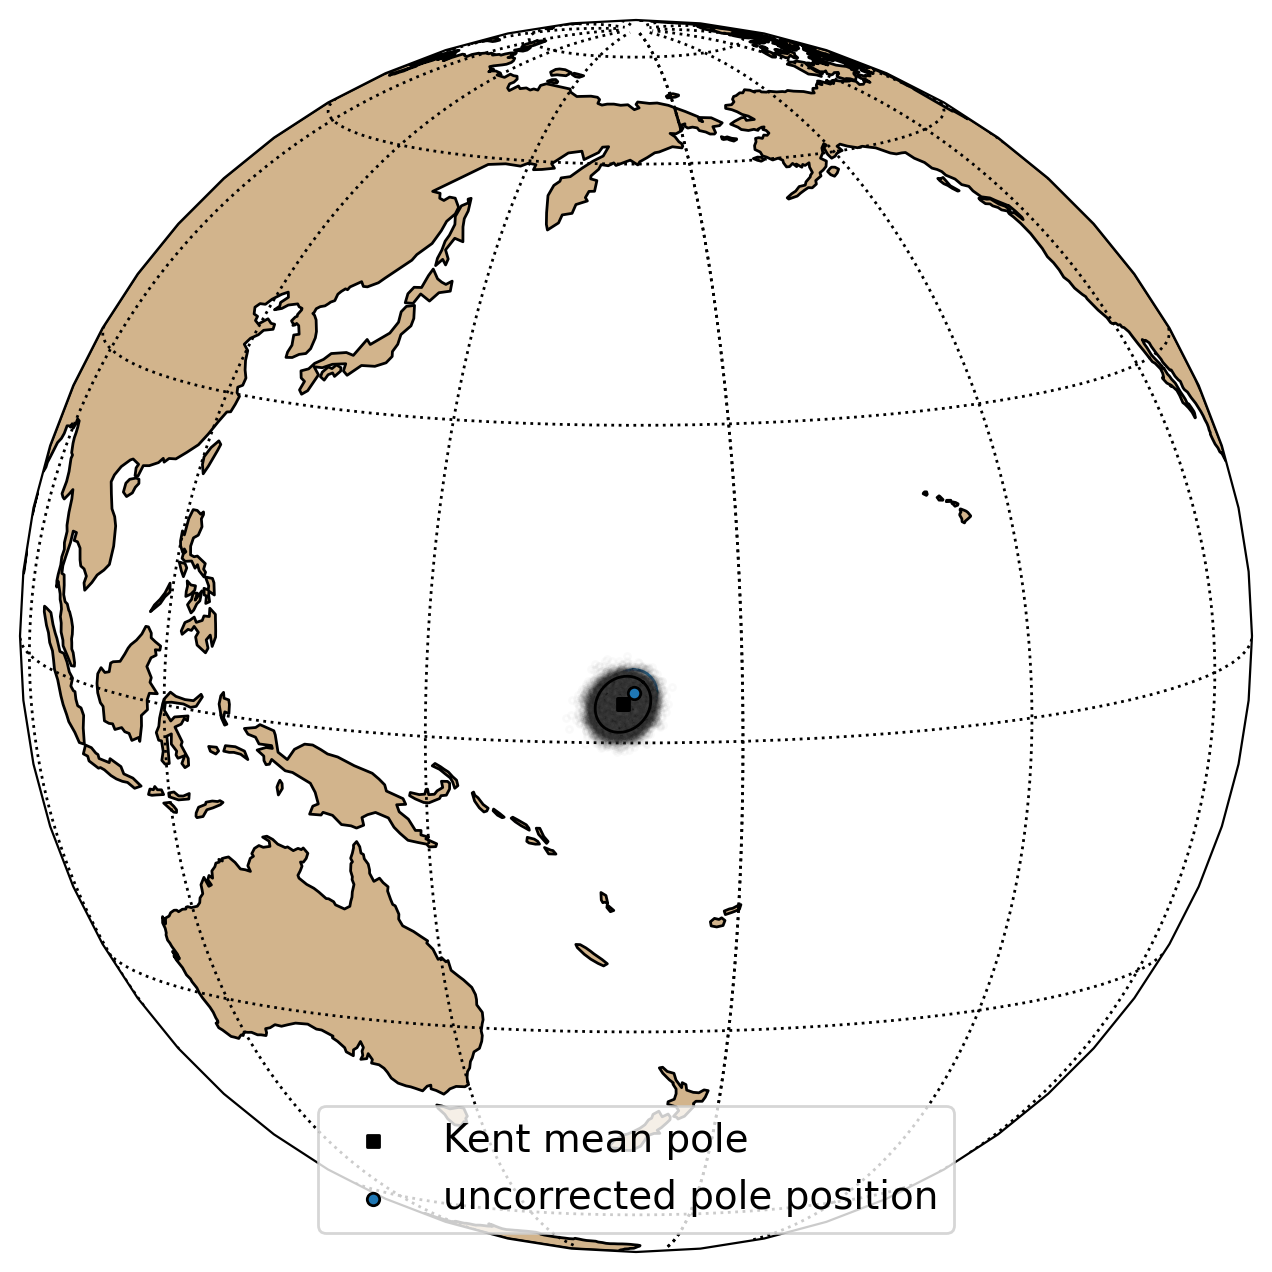


SVEI-corrected pole (find_svei_kent): 3.6°N, 168.8°E
Kent ellipse: zeta95=2.8°, eta95=2.4°  => equal-area A95 approximation = 2.6°
paleolatitude = -5.6°


In [4]:
f_factor = 0.73   # SVEI best-fit flattening factor (95% range 0.59-0.87); Fuentes et al. (2025)

wp_corr = wp_HT.copy()
wp_corr['dir_inc'] = ipmag.unsquish(wp_HT['dir_inc'].tolist(), f_factor)
corr_dir = ipmag.fisher_mean(dec=wp_corr['dir_dec'].tolist(), inc=wp_corr['dir_inc'].tolist())
print('Inclination-corrected mean direction (f = 0.73):')
ipmag.print_direction_mean(corr_dir)

wp_corr = ipmag.vgp_calc(wp_corr, tilt_correction='no', site_lon='lon', site_lat='lat',
                         dec_is='dir_dec', inc_is='dir_inc')
corr_pole = ipmag.fisher_mean(wp_corr['vgp_lon'].tolist(), wp_corr['vgp_lat'].tolist())
print('\nInclination-corrected pole (f = 0.73):')
ipmag.print_pole_mean(corr_pole)

# Reproduce the corrected pole and its Kent-ellipse uncertainty by running the
# SVEI Monte Carlo on the data (ipmag.find_svei_kent; Pierce et al., 2022). The
# flattening range f = 0.59-0.87 is the find_flat SVEI result of Fuentes et al. (2025).
wp_HT_di = ipmag.make_di_block(wp_HT['dir_dec'].tolist(), wp_HT['dir_inc'].tolist())
kent, paleolats = ipmag.find_svei_kent(wp_HT_di, study_lat, study_lon - 360,
                                       0.59, 0.87, n=1000,
                                       central_latitude=10, central_longitude=170,
                                       return_kent_stats=True, return_paleolats=True,
                                       random_seed=23)
zeta95, eta95 = kent['Zeta'], kent['Eta']
a95_kent = pt.kent_a95_approx(zeta95, eta95)
print(f"\nSVEI-corrected pole (find_svei_kent): {kent['inc']:.1f}\u00b0N, {kent['dec']:.1f}\u00b0E")
print(f"Kent ellipse: zeta95={zeta95:.1f}\u00b0, eta95={eta95:.1f}\u00b0  "
      f"=> equal-area A95 approximation = {a95_kent:.1f}\u00b0")
print(f"paleolatitude = {np.mean(paleolats):.1f}\u00b0")

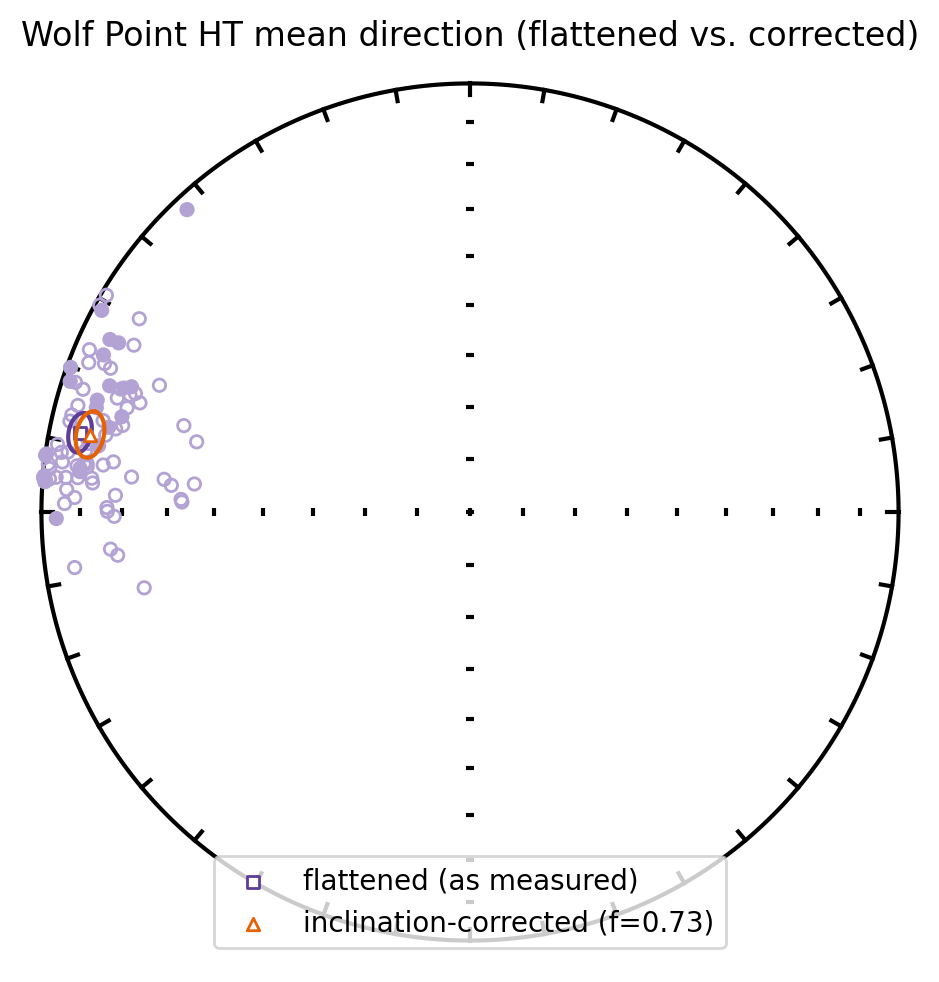

In [5]:
# flattened vs. inclination-corrected mean directions (equal-area)
ipmag.plot_net()
ipmag.plot_di(di_block=ipmag.make_di_block(wp_HT['dir_dec'].tolist(), wp_HT['dir_inc'].tolist()),
              color='#b3a2d4', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='#5e3c99', marker='s', label='flattened (as measured)')
ipmag.plot_di_mean(corr_dir['dec'], corr_dir['inc'], corr_dir['alpha95'],
                   color='#e66101', marker='^', label='inclination-corrected (f=0.73)')
plt.legend(loc='lower center')
plt.title('Wolf Point HT mean direction (flattened vs. corrected)')
plt.show()

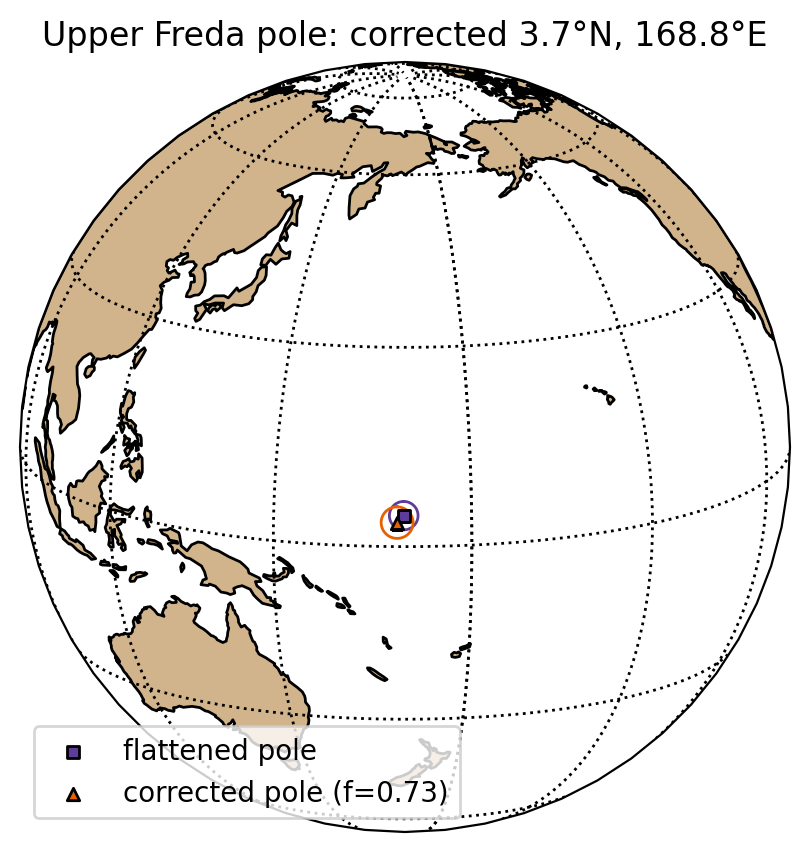

In [6]:
# flattened vs. inclination-corrected poles (orthographic)
ax_o = ipmag.make_orthographic_map(central_longitude=170, central_latitude=15, figsize=(5, 5))
ipmag.plot_pole(ax_o, flat_pole['dec'], flat_pole['inc'], flat_pole['alpha95'],
                marker='s', color='#5e3c99', label='flattened pole')
ipmag.plot_pole(ax_o, corr_pole['dec'], corr_pole['inc'], corr_pole['alpha95'],
                marker='^', color='#e66101', label='corrected pole (f=0.73)')
plt.legend(loc='lower left')
plt.title(f"Upper Freda pole: corrected {corr_pole['inc']:.1f}°N, {corr_pole['dec']:.1f}°E")
plt.show()

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': 169.8670071821571,
 'Inc': 4.674478393049299,
 'N': 90,
 'Mu': 1.8025526474886542,
 'Mu_critical': 1.207,
 'Me': 0.5760843135610102,
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

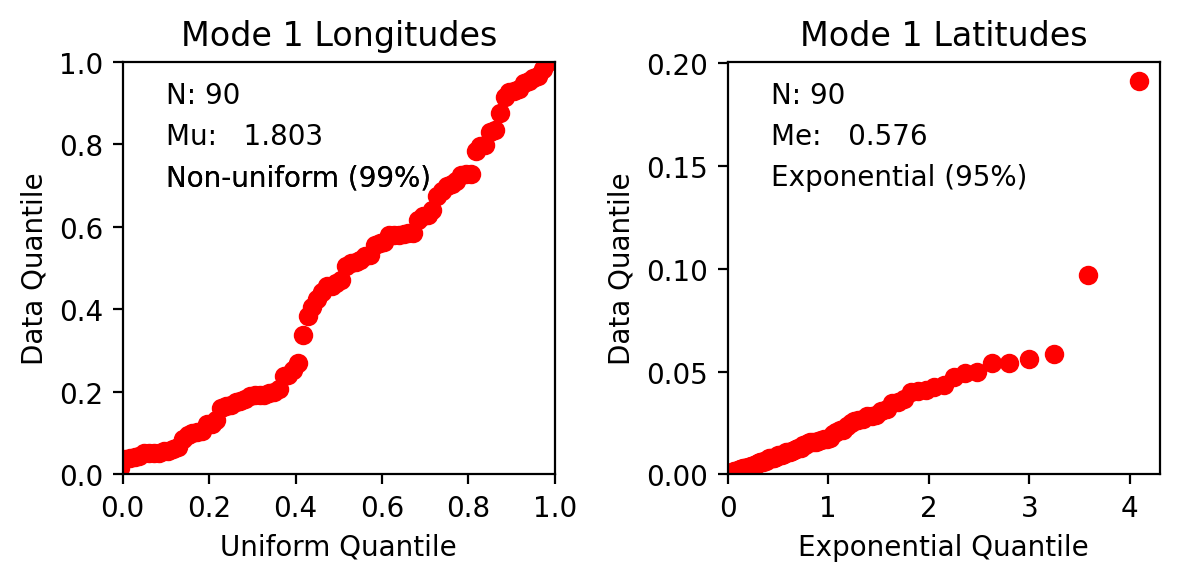

In [7]:
fishqq_result = pt.fishqq_vgps(wp_HT, unify_polarity=False)
fishqq_result

## Pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


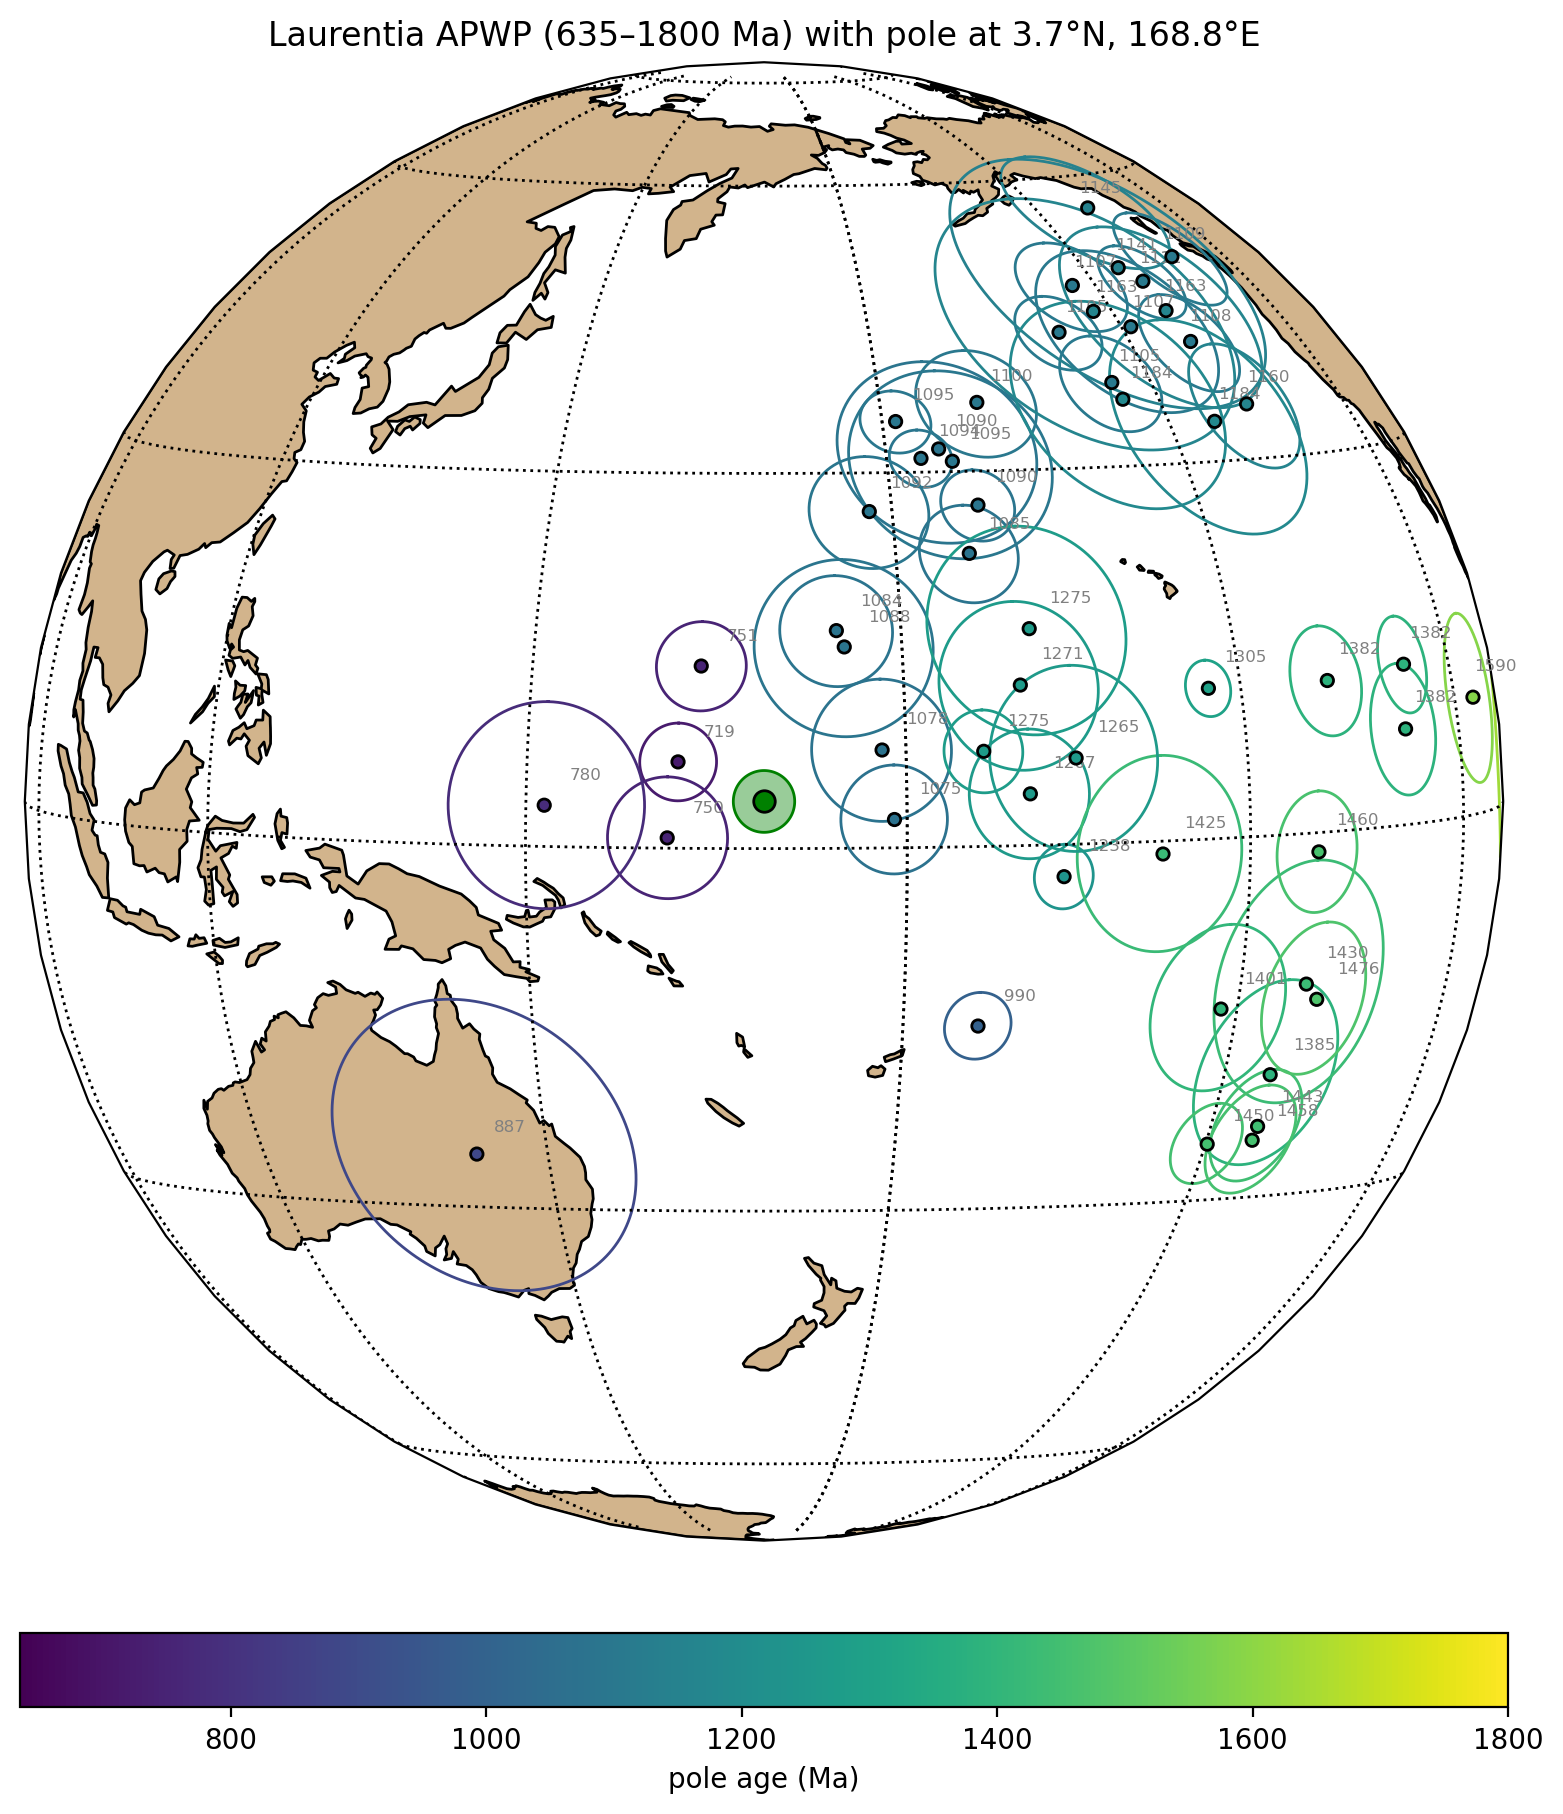

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, corr_pole['inc'], corr_pole['dec'], corr_pole['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=corr_pole['dec'], central_latitude=corr_pole['inc'])
plt.show()

## R2: Deenen test and PSV sampling

The Wolf Point section was sampled at high stratigraphic resolution to capture
independent snapshots of paleosecular variation (Sapienza et al., 2023, sampling
strategy). The Deenen et al. (2011) A95 envelope is evaluated on the corrected
VGP distribution (N = 90 specimen readings). The corrected directional Fisher
precision (k ≈ 21) lies within the 10–70 PSV-averaging window. The SVEI
elongation/inclination analysis of Fuentes et al. (2025) is the basis for the
flattening correction above.

A_95 of 2.4 passes Deenen et al. (2011) criteria of being between 2.0 and 4.8 for this number of sites

Corrected pole: A95 = 2.4°, k = 40.2, N = 90
Corrected directional k = 20.1 (PSV window 10-70)


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

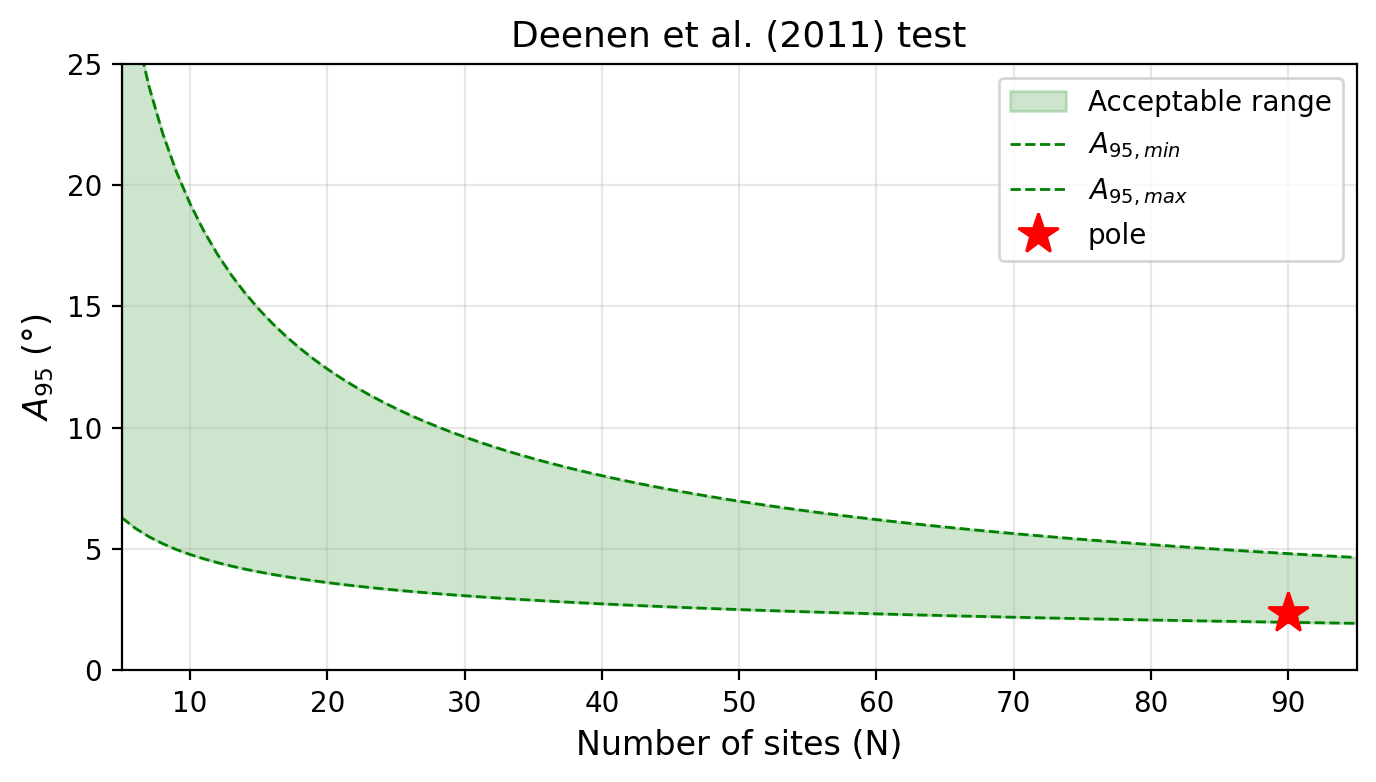

In [9]:
pt.Deenen_test(corr_pole['n'], corr_pole['alpha95'])
print(f"\nCorrected pole: A95 = {corr_pole['alpha95']:.1f}°, k = {corr_pole['k']:.1f}, N = {corr_pole['n']}")
print(f"Corrected directional k = {corr_dir['k']:.1f} (PSV window 10-70)")
pt.plot_Deenen_test(corr_pole)

## R7: Comparison with younger Laurentia poles

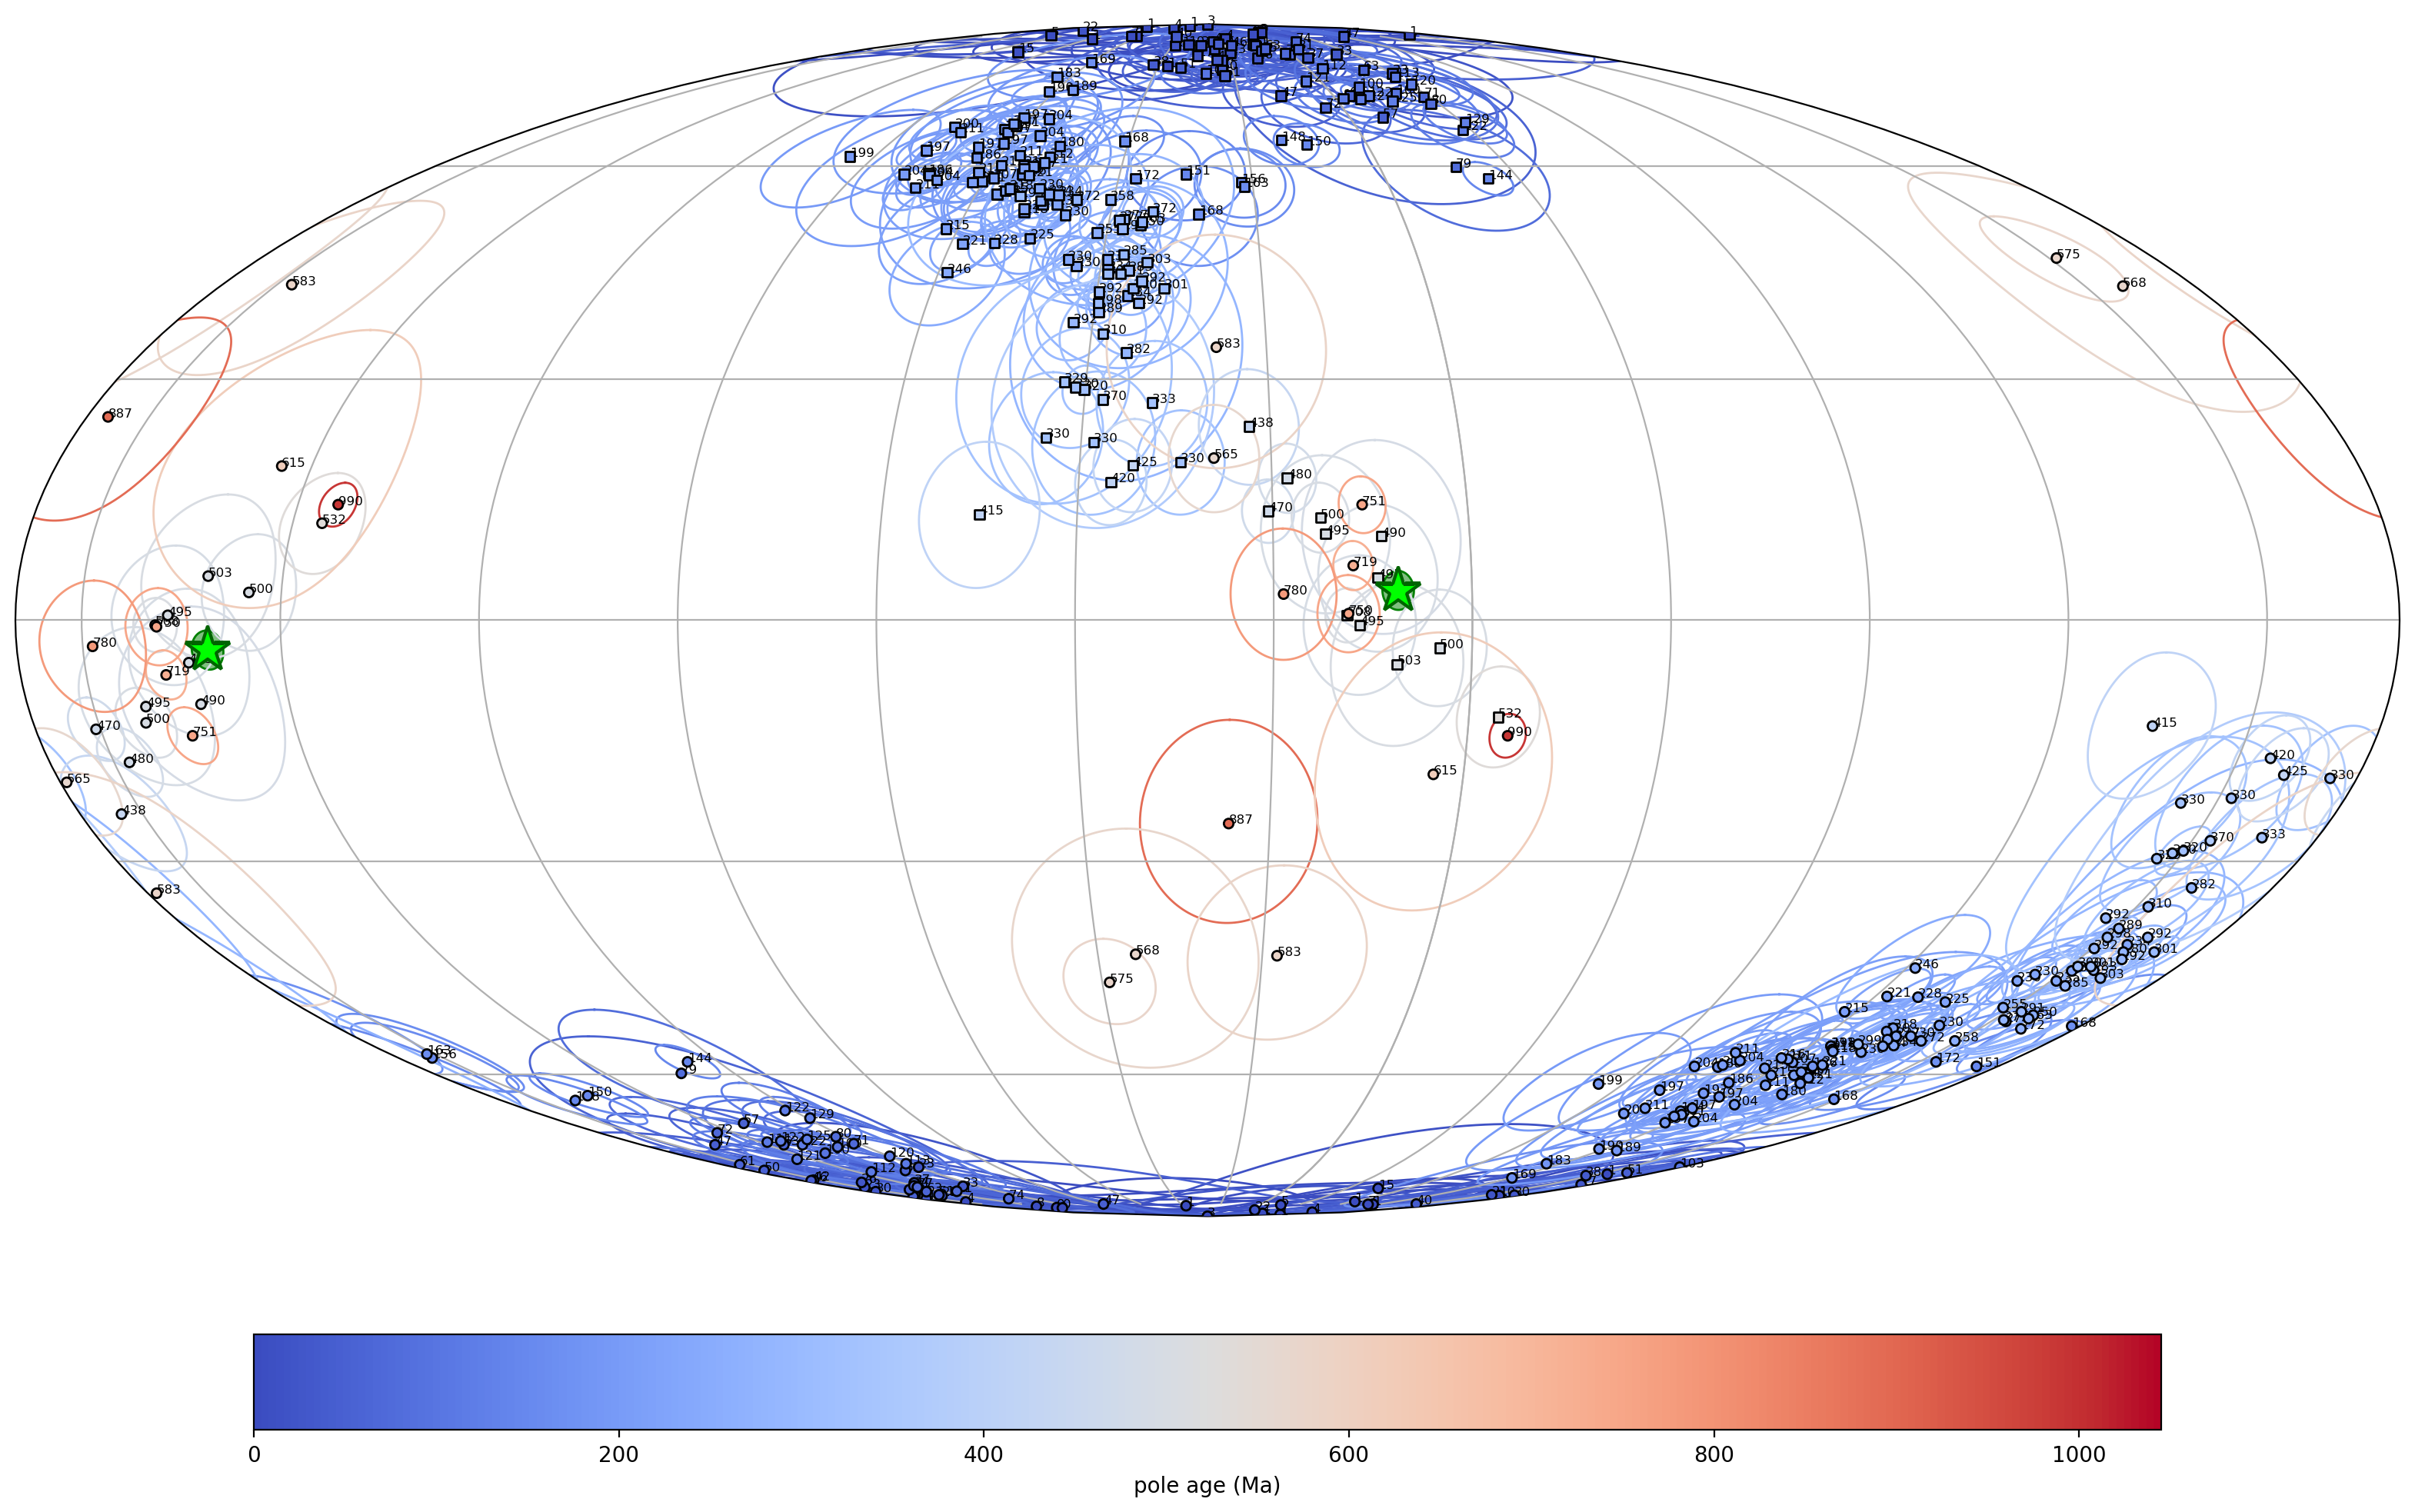

<GeoAxesSubplot:>

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Upper Freda Formation',
                     Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=corr_pole['inc'], pole_plon=corr_pole['dec'],
                     pole_A95=corr_pole['alpha95'], pole_age=1045)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | Best estimate *ca.* 1045 Ma from the Bayesian thermal-subsidence age model of Fuentes et al. (2025): 1045.0 Ma with 95% credible bounds 1063.2 / 1031.7 Ma (+18.2/−13.3 Ma), integrating the U-Pb CA-ID-TIMS detrital-zircon MDA of 1051.6 ± 1.1 Ma (Hodgin et al., 2024) and minimum ages from Rb-Sr biotite (1049 ± 19 Ma; Cannon, 1992) and U-Pb calcite on the Douglas Fault (1049 ± 13 Ma; Hodgin et al., 2024). The asymmetric +18.2 Ma upper bound slightly exceeds ±15 Ma. |
| 2 | Techniques and statistical analysis | **1** | Stepwise thermal demagnetization (steps narrowed to 2 °C near the hematite Néel temperature) with PCA component fits (PmagPy). Pole from n = 90 Wolf Point HT specimen readings sampled to maximize independent field snapshots; corrected directional Fisher mean dec = 281.5°, inc = −10.4°, α95 = 3.4° (k ≈ 21, within 10–70). |
| 3 | Magnetic mineralogy characterized | **1** | The high-temperature DRM carrier is coarse-grained specularite (>1 µm gray detrital hematite, unblocking near the hematite Néel temperature), identified by high-resolution thermal demagnetization and corroborated by SEM imaging, EDS, and EBSD on polished thick sections; the lower-unblocking pigmentary-hematite CRM is distinguished by temperature and direction. |
| 4 | Field tests constrain age of magnetization | **1** | (a) Positive intraformational conglomerate test (Swanson-Hysell, Fairchild & Slotznick, 2019b) on Freda siltstone intraclasts: high-T specularite (DRM) directions are dispersed and pass the Watson randomness test (positive on DRM) while the mid-T pigmentary-hematite (CRM) directions remain grouped (negative on CRM). (b) Positive bootstrap fold test (Tauxe & Watson, 1994) on combined Freda DRM data (this study + Henry et al., 1977): tightest grouping at 95–102% unfolding (95% CI encompasses 100%). |
| 5 | Structural control / tectonic coherence | **1** | Pole from autochthonous Laurentian cratonic strata. The Wolf Point section was chosen to lie outside the Montreal River Monocline / Ashland Syncline structural domain (which shows vertical-axis rotation), with nearly flat-lying (~4°) beds. Inclination-shallowing correction applied via the SVEI method (f = 0.73; 95% range 0.59–0.87) with uncertainty propagated through the Monte Carlo approach of Pierce et al. (2022). |
| 6 | Presence of reversals | **0** | All Wolf Point DRM specimen directions are of a single (westerly, shallow-up) polarity. No reversal test is possible for this pole. |
| 7 | No resemblance to younger poles | **1** | The pole at 3.6°N / 168.8°E sits at the young end of the Keweenawan Track, well-resolved from all Phanerozoic Laurentia pole positions; the positive intraclast conglomerate and fold tests independently constrain the magnetization to predate the *ca.* 1049 Ma rift inversion. |
| | **Total R-score** | **5/7** | |

The corrected pole is reported with a Kent ellipse (ζ95 ≈ 2.8°, η95 ≈ 2.4°,
reproduced with `ipmag.find_svei_kent` above and matching Fuentes et al., 2025)
rather than a circular A95; the Nordic A95 is the equal-area approximation
`sqrt(ζ95·η95)`.

## Nordic workshop ranking

Proposed: **B**. This is a new pole (Fuentes et al., 2025) that fills the late
Keweenawan Track. The data and field tests are strong (R3–R5, R7), but R1 is not
met because the asymmetric age uncertainty slightly exceeds ±15 Ma, and R6 fails
(single polarity), giving 5/7. In the Nordic summary the main block records the
as-measured (flattened) pole and the f-block records the inclination-corrected
pole (f = 0.73).

### Upper Freda (HT specularite DRM) pole

The pole reported here is the observed (uncorrected) Fisher mean of the Wolf Point HT specularite DRM virtual geomagnetic poles (`flat_pole`), with the corresponding mean direction of `wp_HT`. There is no "Upper Freda" entry in the Evans et al. (2021) compilation; the closest match is the Henry et al. (1977) Freda Sandstone (High temp.) result, which is from the lower Freda exposures.

| | This study (site VGPs) | Fuentes et al. (2025) | Previous Nordic compilation |
|---|---|---|---|
| Component | HT specularite DRM | HT specularite DRM | High temp. |
| N (sites) | 90 | 90 | 20 |
| N (specimens) | 90 | 90 | 85 |
| Dec (°) | 281.5 | 281.5 | 272.4 |
| Inc (°) | −7.9 | −7.9 | 1.5 |
| k (direction) | 28.4 | 28.4 | 32.0 |
| α95 (direction, °) | 2.8 | 2.8 | 5.9 |
| Pole lat (°N) | 4.7 | 4.7 | 2.2 |
| Pole lon (°E) | 169.8 | 169.8 | 179.0 |
| A95 | 2.1 | 2.1 | 4.2 |
| pole (°) | — | — | — |
| dp / dm (°) | — | — | 3.0 / 5.9 |


In [11]:
# Nordic summary: main block = flattened (as-measured); f-block = inclination-corrected.
sites_df = pd.DataFrame({'dir_tilt_correction': [100] * len(wp_HT),
                         'dir_n_samples': [1] * len(wp_HT)})   # N = 90 specimen readings

Upper_Freda_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Upper Freda Formation',
    sites=sites_df,
    dir_mean=dir_mean,
    pole_mean=flat_pole,
    study_lon=study_lon,
    study_lat=study_lat,
    lithology='sedimentary',
    component_comment='High-temperature specularite detrital remanent magnetization (DRM)',
    tests='g+ (positive intraformational conglomerate test; Swanson-Hysell, Fairchild & Slotznick, 2019b) and f+ (positive bootstrap fold test, 95-102% unfolding; this study + Henry et al., 1977)',
    R1=0,
    R2=1,
    R3=1,
    R4='Gf',
    R5=1,
    R6=0,
    R7=1,
    Grade='B',
    nominal_age=1045,
    lomagage=1031.7,
    himagage=1063.2,
    REF_method='Bayesian thermal-subsidence age model 1045.0 (+18.2/-13.3) Ma (Fuentes et al., 2025), integrating U-Pb CA-ID-TIMS detrital-zircon MDA 1051.6 ± 1.1 Ma and U-Pb calcite 1049 ± 13 Ma (Hodgin et al., 2024) and Rb-Sr biotite 1049 ± 19 Ma (Cannon, 1992).',
    POLE_AUTHORS='Fuentes, A. J., Fairchild, L. M., Hodgin, E. B., Alemu, T., & Swanson-Hysell, N. L.',
    YEAR=2025,
    JOURNAL='Journal of Geophysical Research: Solid Earth',
    VOLUME=130,
    VPAGES='e2025JB031794',
    TITLE="Termination of Laurentia's rapid plate motion at the start of the Grenvillian Orogeny",
    COMMENT=pt.corrected_pole_note('SVEI (Tauxe et al., 2024)', corr_pole['inc'], corr_pole['dec'], f=f_factor, f_range=(0.59, 0.87), zeta95=zeta95, eta95=eta95, monte_carlo='Pierce et al. (2022) Monte Carlo') + ' Upper Freda pole from the Wolf Point section, HT specularite DRM (n=90, MagIC 20259). Nordic main and f-blocks both use the blanket sedimentary f=0.6 inclination correction.'
)
Upper_Freda_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Upper Freda Formation,,High-temperature specularite detrital remanent...,g+ (positive intraformational conglomerate tes...,100,47.0,271.0,90,90,...,1063,Bayesian thermal-subsidence age model 1045.0 (...,Upper Freda Formation,"Fuentes, A. J., Fairchild, L. M., Hodgin, E. B...",2025,Journal of Geophysical Research: Solid Earth,130,e2025JB031794,Termination of Laurentia's rapid plate motion ...,Study inclination-corrected pole - SVEI (Tauxe...


In [12]:
pt.save_nordic_summary(Upper_Freda_summary, '1045_Upper_Freda')

'../data/nordic_summaries/1045_Upper_Freda.csv'